In [ ]:
def serial_ports():
    """ Lists serial port names

        :raises EnvironmentError:
            On unsupported or unknown platforms
        :returns:
            A list of the serial ports available on the system
    """
    if sys.platform.startswith('win'):
        ports = ['COM%s' % (i + 1) for i in range(256)]
    elif sys.platform.startswith('linux') or sys.platform.startswith('cygwin'):
        # this excludes your current terminal "/dev/tty"
        ports = glob.glob('/dev/tty[A-Za-z]*')
    elif sys.platform.startswith('darwin'):
        ports = glob.glob('/dev/tty.*')
    else:
        raise EnvironmentError('Unsupported platform')

    result = []
    for port in ports:
        try:
            s = serial.Serial(port)
            s.close()
            result.append(port)
        except (OSError, serial.SerialException):
            pass
    return result

In [ ]:
#to test single or 2 bulbs

#before running with PMM, try this to see if rs485 working right
#make sure to run previous cell first to define serial_ports

import minimalmodbus
import serial
import sys
import glob
 
#print(serial_ports())
bulb101 = minimalmodbus.Instrument(port = '/dev/tty.usbserial-B003LY1G',\
                                       slaveaddress = 101,\
                                       mode = minimalmodbus.MODE_RTU)
bulb102 = minimalmodbus.Instrument(port = '/dev/tty.usbserial-B003LY1G',\
                                      slaveaddress = 1,\
                                      mode = minimalmodbus.MODE_RTU) # automatically at saveaddress=1
bulb101.serial.baudrate = 9600
bulb101.write_register(0x1001, 10, functioncode = 6) #1001 to change power current
#bulb101.write_register(0x1008, 101, functioncode = 6) #1008 to change address name

bulb102.serial.baudrate = 9600
#bulb102.write_register(0x1001, 230, functioncode = 6)
bulb102.write_register(0x1008, 52, functioncode = 6) #1008 to change address name

 

In [4]:
import os
print(os.getcwd())



/Users/scsl/PMM-Design/scripts


In [1]:
###run this to see if PMM working

import sys
import os
# Add the parent folder (PMM-Design) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from PMM.PMMInSitu import PMMInSitu
PMM = PMMInSitu('../confs/conf_test.yaml')

# Run these 2 lines:
# PMM.Set_Bulb_VI('all', 10, 2) #set bulbs(all, volts, amps)
# PMM.Activate_Bulb('all')

# OR run these 2 lines:
# PMM.Config_Check()
PMM.Deactivate_Bulb('all')


RuntimeError: One or more of the ports in the config file                                    is not connected

In [4]:
import sys, platform; print(sys.executable, platform.machine())


/Users/scsl/miniforge3/envs/pmm_x86/bin/python arm64


checking port /dev/tty.usbserial-B003LKT9
checking supply:  1
checking supply:  2
checking supply:  3
checking supply:  4
checking supply:  5
checking supply:  6
checking supply:  7
checking supply:  8
checking supply:  9
checking supply:  10
checking port /dev/tty.usbserial-B0032GMG
checking supply:  11
checking supply:  12
checking supply:  13
checking supply:  14
checking supply:  15
checking supply:  16
checking supply:  17
checking supply:  18
checking supply:  19
checking supply:  20
checking port /dev/tty.usbserial-B003L2CD
checking supply:  21
checking supply:  22
checking supply:  23
checking supply:  24
checking supply:  25
checking supply:  26
checking supply:  27
checking supply:  28
checking supply:  29
checking supply:  30
checking port /dev/tty.usbserial-B003LJKJ
checking supply:  31
checking supply:  32
checking supply:  33
checking supply:  34
checking supply:  35
checking supply:  36
checking supply:  37
checking supply:  38
checking supply:  39
checking supply:  40
c

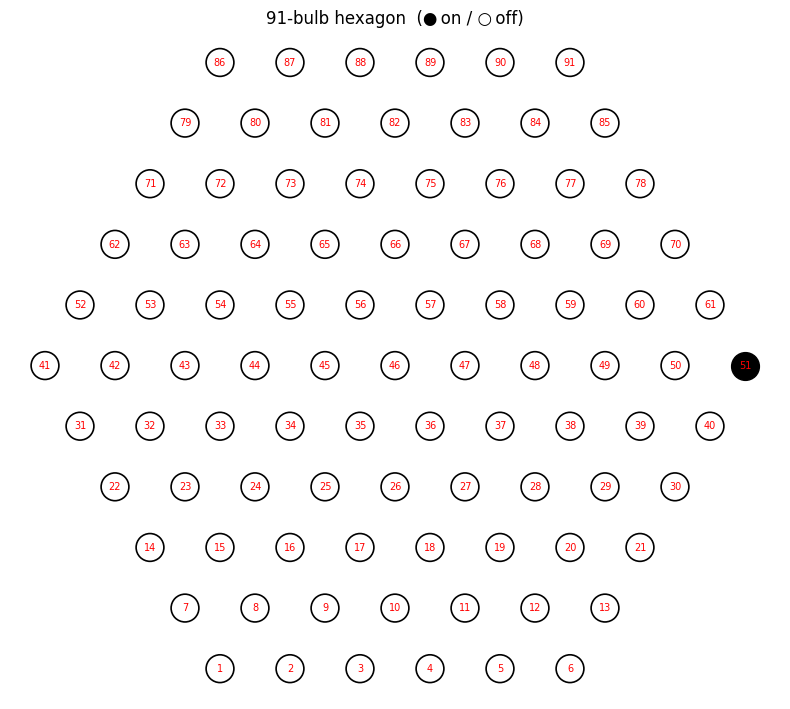

In [ ]:
###############YAY USE THIS#######################################
#(now making sure i can set individual bulbs not just all)
####run PREVIOUS cell to get plot

from PMM.PMMInSitu import PMMInSitu
PMM = PMMInSitu('../confs/conf_test.yaml')

import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from collections.abc import Iterable


def _cmd_with_retry(cmd, addr, cmd_args, cmd_kwargs, tries=3, delay=0.3):
    """Calls a bulb command and automatically retries on any exception"""
    for attempt in range(tries):
        try:
            cmd(addr, *cmd_args, **cmd_kwargs)
            return True
        except Exception as err:
            if attempt == tries - 1:
                print(f"[FAIL] Addr {addr}: {cmd.__name__} → {err}")
            else:
                print(f"[WARN] Addr {addr}: {cmd.__name__} failed "
                      f"({attempt+1}/{tries}); retrying…")
                time.sleep(delay)
    return False


def parallel_bulb_op(
        pmm,
        cmd_name,
        *cmd_args,        # extra positional args for the command
        bulbs='all',      # NEW ─ int | Iterable[int] | 'all'
        tries=3,
        delay=0.3,
        max_workers=None,
        **cmd_kwargs      # extra keyword args for the command
):
    """
    Run `pmm.<cmd_name>(addr, *cmd_args, **cmd_kwargs)` in parallel
    across RS-485 buses, column-by-column.

    Parameters
    ----------
    pmm   : PMMInSitu instance
    cmd_name : str   – method name in PMMInSitu (e.g. "Set_Bulb_VI")
    bulbs : int | Iterable[int] | "all"
        • int            → that single address
        • iterable[int]  → explicit list/tuple/set of addresses
        • "all" (str)    → every address in the config
    ...

    Examples
    --------
    • Turn on bulb 3 with 30 V, 5 A:
        parallel_bulb_op(PMM, "Set_Bulb_VI", 30, 5, bulbs=3)
        parallel_bulb_op(PMM, "Activate_Bulb", bulbs=3)

    • Turn on bulbs 3, 7, 11:
        parallel_bulb_op(PMM, "Activate_Bulb", bulbs=[3, 7, 11])

    • Full-array ops (unchanged):
        parallel_bulb_op(PMM, "Deactivate_Bulb", bulbs='all')
    """
    cmd = getattr(pmm, cmd_name)

    # Normalise the target set -----------------------------------------------
    all_addrs = {a for lst in pmm.config["serial_ports"].values() for a in lst}
    if bulbs == 'all':
        target_set = all_addrs
    elif isinstance(bulbs, int):
        target_set = {bulbs}
    elif isinstance(bulbs, Iterable):
        target_set = set(bulbs)
    else:
        raise ValueError("bulbs must be int, iterable of ints, or 'all'")

    # Keep each USB port open to avoid OS churn
    for inst in pmm.bulbs['all'].values():
        inst.serial.close_port_after_each_call = False

    # Build per-bus, column-aligned lists but only with targets ---------------
    port_to_addrs = {
        port: [a for a in addr_list if a in target_set]
        for port, addr_list in pmm.config["serial_ports"].items()
    }
    addr_lists = [lst for lst in port_to_addrs.values() if lst]   # drop empties
    if not addr_lists:
        print("No matching bulb addresses!")
        return

    n_cols = max(len(lst) for lst in addr_lists)
    workers = max_workers or len(addr_lists)

    # Parallel loop -----------------------------------------------------------
    with ThreadPoolExecutor(max_workers=workers) as pool:
        for col in range(n_cols):
            futures = [
                pool.submit(
                    _cmd_with_retry,
                    cmd,
                    lst[col],
                    cmd_args,
                    cmd_kwargs,
                    tries,
                    delay,
                )
                for lst in addr_lists
                if col < len(lst)
            ]
            for fut in as_completed(futures):
                fut.result()

    # Final broadcast remains, but only for full-array ops --------------------
    if bulbs == 'all' and cmd_name in ("Activate_Bulb", "Deactivate_Bulb"):
        try:
            cmd("all", *cmd_args, **cmd_kwargs)
        except Exception:
            pass


# ─────────────────────────────────────────────────────────
# EXAMPLES
# ---------------------------------------------------------------------------

# 1) Single bulb
#parallel_bulb_op(PMM, "Set_Bulb_VI", 5, 1, bulbs=51) 
#parallel_bulb_op(PMM, "Activate_Bulb", bulbs=51)
#parallel_bulb_op(PMM, "Deactivate_Bulb", bulbs=51)

# 2) A few bulbs
# parallel_bulb_op(PMM, "Set_Bulb_VI", 30, 5, bulbs=3, 7, 11)
# parallel_bulb_op(PMM, "Activate_Bulb", bulbs=[3, 7, 11])
# parallel_bulb_op(PMM, "Deactivate_Bulb", bulbs=[3, 7, 11])

# 3) Entire array (unchanged use)
parallel_bulb_op(PMM, "Set_Bulb_VI", 5, 1,  bulbs='all')
parallel_bulb_op(PMM, "Activate_Bulb",        bulbs='all')
parallel_bulb_op(PMM, "Deactivate_Bulb",      bulbs='all')

plot_hex_bulbs(PMM)


In [2]:
#check port for VNA
# install visa https://www.rohde-schwarz.com/us/applications/r-s-visa-application-note_56280-148812.html

from RsInstrument import *

# List *everything* the VISA layer can open right now
print(RsInstrument.list_resources('?*INSTR'))
# USB only
print(RsInstrument.list_resources('?*USB*')) #not working??? 

/Users/bronstek/miniforge3/envs/pmm_x86/lib/python3.10/site-packages/pyvisa_py/tcpip.py:122: UserWarning: TCPIP::hislip resource discovery requires the zeroconf package to be installed... try 'pip install zeroconf'
  warnings.warn(


('ASRL/dev/cu.debug-console::INSTR', 'ASRL/dev/cu.usbserial-B00295EU::INSTR', 'ASRL/dev/cu.usbserial-B0032389::INSTR', 'ASRL/dev/cu.usbserial-B0032GQ2::INSTR', 'ASRL/dev/cu.usbserial-B001K6BU::INSTR', 'ASRL/dev/cu.usbserial-B0019Q3M::INSTR', 'ASRL/dev/cu.usbserial-B0032GMG::INSTR', 'ASRL/dev/cu.usbserial-B003LKT9::INSTR', 'ASRL/dev/cu.usbserial-B003LJKJ::INSTR', 'ASRL/dev/cu.usbserial-B0013LEA::INSTR', 'ASRL/dev/cu.usbserial-B003L2CD::INSTR', 'ASRL/dev/cu.Bluetooth-Incoming-Port::INSTR')
('ASRL/dev/cu.usbserial-B00295EU::INSTR', 'ASRL/dev/cu.usbserial-B0032389::INSTR', 'ASRL/dev/cu.usbserial-B0032GQ2::INSTR', 'ASRL/dev/cu.usbserial-B001K6BU::INSTR', 'ASRL/dev/cu.usbserial-B0019Q3M::INSTR', 'ASRL/dev/cu.usbserial-B0032GMG::INSTR', 'ASRL/dev/cu.usbserial-B003LKT9::INSTR', 'ASRL/dev/cu.usbserial-B003LJKJ::INSTR', 'ASRL/dev/cu.usbserial-B0013LEA::INSTR', 'ASRL/dev/cu.usbserial-B003L2CD::INSTR', 'PRLGX-ASRL::/dev/cu.usbserial-B00295EU::INTFC', 'PRLGX-ASRL::/dev/cu.usbserial-B0032389::INTFC'

In [3]:
#vna
from PMM.PMMInSitu import PMMInSitu

resource = 'USB0::0x0AAD::0x01C0::101603::INSTR' 
vna = RsInstrument(resource, options="SelectVisa='rs'")


In [ ]:
#mirror plot

from RsInstrument import RsInstrument
import numpy as np
import matplotlib.pyplot as plt

#addr = 'USB0::0x0AAD::0x0119::022019943::INSTR' 
addr = 'USB0::0x0AAD::0x01C0::101603::INSTR'
vna  = RsInstrument(addr)
#vna  = RsInstrument(addr, reset=True, id_query=True, options="SelectVisa='rs'")
#^double check all those defaults************ (after addresss)
#try new pmm environment
#try restart
#rosetta

# Basic preset
vna.write_str('SYST:PRES; *CLS')

# Channel 1 sweep and trace definition
vna.write_str('SENS1:FREQ:STAR 2e9')
vna.write_str('SENS1:FREQ:STOP 3e9')
vna.write_str('SENS1:SWE:POIN 801')
vna.write_str('CALC1:PAR:DEF "Meas",S21')
vna.write_str('CALC1:PAR:SEL "Meas"')
vna.write_str('CALC1:FORM MLOG')

# Trigger a single sweep and wait
vna.write_str('INIT:IMM; *WAI')

# Fetch frequency axis and trace data
f     = np.array(vna.query_float_list('SENS1:FREQ:DATA?'))
s21db = np.array(vna.query_float_list('CALC1:DATA:FDAT?'))

vna.close()   # always clean up

# Plot
plt.plot(f/1e9, s21db)
plt.xlabel('Frequency (GHz)')
plt.ylabel('S21 (dB)')
plt.title('ZNB40 S21')
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
from PMM.PMMInSitu import PMMInSitu
PMM = PMMInSitu('../confs/conf_test.yaml')

rho_settings = np.random.rand(91) * 5.0 
wp_max_setting = 15.0

PMM.ArraySet_Rho(rho_settings, wp_max_setting)

print("ArraySet_Rho command has been sent successfully.")


In [16]:
# testing BulbSetting_BOLSIG
import numpy as np
from PMM.PMMInSitu import PMMInSitu

# add "@staticmethod" before the function BulbSetting_BOLSIG
# delete self

# One-off test
V, I = PMMInSitu.BulbSetting_BOLSIG(fp=3, knob=0.5, scale=1.0)
print(f"fp=3 GHz  -->  V={V:.2f} V,  I={I:.2f} A")



fp=3 GHz  -->  V=7.59 V,  I=10.00 A


In [ ]:
#Define the initial parameters for the optimization (manual start)

import numpy as np
from PMM.PMMInSitu import PMMInSitu
import time

# 1. Initialize the PMMInSitu class instance
# Make sure the path to your configuration file is correct.
PMM = PMMInSitu('../confs/conf_test.yaml')

# 2. Define the manual rho array you want to test
initial_rho = np.zeros(91)
on_value = 18.0 
bulbs_to_turn_on = [41, 52, 62, 71, 79, 86, 1, 2, 3, 4, 5, 6, 9, 10, 11, 12, 13, 18, 19, 20, 21, 27, 28, 29, 30, 37, 38, 39, 40, 48, 49, 50, 51, 59, 60, 61, 68, 69, 70, 77, 78, 84, 85, 91] # <-- Change these addresses to test different bulbs

for bulb_address in bulbs_to_turn_on:
    initial_rho[bulb_address - 1] = on_value

# 3. Set the max plasma frequency (must be a realistic value for your setup)
# This should match the value from your main optimization script.
max_plasma_freq_GHz = 12.0 


# --- EXECUTION AND CLEANUP ---

try:
    # 4. Activate the array using your manual rho configuration
    print("Activating the array with your manual configuration...")
    print(f"Bulbs to check: {bulbs_to_turn_on}")
    
    PMM.ArraySet_Rho(
        rho=initial_rho,
        wp_max=max_plasma_freq_GHz,
        knob=0.5,
        scale=1.0
    )

    # 5. Keep bulbs on for inspection
    on_duration = 20  # seconds
    print(f"Bulbs are ON. You have {on_duration} seconds to visually inspect them.")
    time.sleep(on_duration)

finally:
    # 6. CRITICAL: This will run no matter what, ensuring bulbs are turned off.
    print("\nDeactivating all bulbs...")
    PMM.Deactivate_Bulb('all')
    print("Test complete. All bulbs are now off.")

In [ ]:
# See initial parameters for the optimization (manual start)

import numpy as np
from PMM.PMMInSitu import PMMInSitu
import time

# 1. Initialize the PMMInSitu class instance
PMM = PMMInSitu('../confs/conf_test.yaml')

# 2. Define the initial_rho array you want to test
initial_rho = np.zeros(91)
on_value = 19.0 
bulbs_to_turn_on = [41, 52, 62, 71, 79, 86, 1, 2, 3, 4, 5, 6, 9, 10, 11, 12, 13, 18, 19, 20, 21, 27, 28, 29, 30, 37, 38, 39, 40, 48, 49, 50, 51, 59, 60, 61, 68, 69, 70, 77, 78, 84, 85, 91]
for bulb_address in bulbs_to_turn_on:
    initial_rho[bulb_address - 1] = on_value
print(f"Using manual initial_rho with bulbs ON: {bulbs_to_turn_on}")

# 3. Define the core settings needed for the functions
max_plasma_freq_GHz = 12.0
operating_freq_GHz = 6.0
knob = 0.5
scale = 1.0

try:
    # 4. Activate the array with your rho configuration
    print("\nActivating array...")
    PMM.ArraySet_Rho(
        rho=initial_rho,
        wp_max=max_plasma_freq_GHz,
        knob=knob,
        scale=scale
    )
    
    # Let the plasma stabilize for a moment
    time.sleep(1) 

    # 5. Get the S-parameter data from the VNA
    print("Getting VNA measurement...")
    freq, S21, S31 = PMM.Get_S21_S31()
    print("Measurement complete.")

finally:
    # 6. CRITICAL: Deactivate all bulbs
    print("Deactivating all bulbs...")
    PMM.Deactivate_Bulb('all')
    print("Bulbs are now off.")

# 7. Generate and display the graph of the measurement
print("\nGenerating plot...")
PMM.Trans_Plot_2Port(
    savepath='./initial_rho_test_plot.pdf', # File will be saved here
    freq=freq/1e9,
    S21=S21,
    S31=S31,
    fpm=max_plasma_freq_GHz,
    k=knob,
    S=scale,
    f=[operating_freq_GHz] # Draws a line at target frequency
)

In [ ]:
# Run optimize_waveguide stochastic

import numpy as np
from PMM.PMMInSitu import PMMInSitu

# 1. Initialize the PMMInSitu class instance
PMM = PMMInSitu('../confs/conf_test.yaml')

# 2. Define the initial parameters for the optimization
# 'rho' is the initial guess for the plasma densities. 
#initial_rho = np.random.rand(91) * 2.0  # A random starting point.

initial_rho = np.zeros(91)
on_value = 19.0 
bulbs_to_turn_on = [41, 52, 62, 71, 79, 86, 1, 2, 3, 4, 5, 6, 9, 10, 11, 12, 13, 18, 19, 20, 21, 27, 28, 29, 30, 37, 38, 39, 40, 48, 49, 50, 51, 59, 60, 61, 68, 69, 70, 77, 78, 84, 85, 91] # <-- Change these addresses to test different bulbs
# Set the 'on_value' for the specified bulbs.
# Subtract 1 because array indices start at 0 (e.g., bulb 1 is at index 0).
for bulb_address in bulbs_to_turn_on:
    initial_rho[bulb_address - 1] = on_value
print(f"Manually set starting bulbs to ON: {bulbs_to_turn_on}")


# 3. Define the core optimization settings
epochs = 60                 # The number of full optimization cycles to run.
max_plasma_freq_GHz = 12    # The target maximum plasma frequency (fpm) in GHz to match max voltage.
operating_freq_GHz = 6      # The frequency (f) you want the waveguide to work at.
knob = 0.5                  # The bulb fit parameter 'k' (typically 0.0 to 1.0).
scale = 1.0                 # The bulb fit scaling factor 'S'.
warmup_time = 2             # Number of warm-up cycles. For a quick test, use a small
                            # number like 1 or 2. For a real experiment, use 10+.

# 4. Call the optimization function with your defined parameters
print("Starting waveguide optimization...")
PMM.optimize_waveguide_stochastic(
    epochs=epochs,
    rho=initial_rho,
    fpm=max_plasma_freq_GHz,
    k=knob,
    S=scale,
    f=operating_freq_GHz,
    wu=warmup_time, 
    snapback=True,
    sample=9,
    progress_dir = '../outputs/waveguide_stochastic',
    alpha = 0.0005
)

print("Optimization finished.")

In [ ]:
#OLD VERSION
# Run Bayesian optimize_waveguide_bayes_old

import numpy as np
from PMM.PMMInSitu import PMMInSitu

# silence extra print statements
import types
def _silent_retry(self, cmd, addr, cmd_args, cmd_kwargs, tries=3, delay=0.6):
    import time
    for attempt in range(tries):
        try:
            cmd(addr, *cmd_args, **cmd_kwargs)
            return True
        except Exception:
            if attempt < tries - 1:
                time.sleep(delay)
    return False

PMM = PMMInSitu('../confs/conf_test.yaml')

PMM._cmd_with_retry = types.MethodType(_silent_retry, PMM)

# PMM.verbose = True


# 2. Define the initial parameters for the optimization
initial_rho = np.zeros(91)
# on_value = 19.0 # volts
start_fp = 8.0  # GHz
on_value = PMM.f_a(start_fp) # converts GHz to rho units 
bulbs_to_turn_on = [41, 52, 62, 71, 79, 86, 1, 2, 3, 4, 5, 6, 9, 10, 11, 12, 13, 18, 19, 20, 21, 27, 28, 29, 30, 37, 38, 39, 40, 48, 49, 50, 51, 59, 60, 61, 68, 69, 70, 77, 78, 84, 85, 91]
for bulb_address in bulbs_to_turn_on:
    initial_rho[bulb_address - 1] = on_value
print(f"Manually set starting bulbs to ON: {bulbs_to_turn_on}")


# 3. Define the core optimization settings
epochs = 50                 # The number of full optimization cycles to run.
max_plasma_freq_GHz = 18    # The target maximum plasma frequency (fpm) in GHz.
operating_freq_GHz = 8      # The frequency (f) you want the waveguide to work at.
knob = 0.5                  # The bulb fit parameter 'k'.
scale = 1.0                 # The bulb fit scaling factor 'S'.
warmup_time = 2             # Number of warm-up cycles.

# 5. Call the Bayesian optimization function
print("Starting Bayesian waveguide optimization...")
PMM.optimize_waveguide_bayes(
    epochs=epochs,
    rho=initial_rho,
    fpm=max_plasma_freq_GHz,
    k=knob,
    S=scale,
    f=operating_freq_GHz,
    wu=warmup_time, 
    sample= len(initial_rho), #try 25 if full is too big
    progress_dir='../outputs/waveguide_bayes', 
    n_calls= 5, #(increase?) tries/block
    n_init= 3,
    p_range= 2, #max change delta (too small then stuck, too big then unstable)
    verbose=True
)

print("Bayesian optimization finished.")


In [6]:
#rho test

import numpy as np

rho_test = np.array([
    1.16096141412473E-01, 6.96835569666199E-01, 1.05304286228159E+00,
    0E+00, 7.03455397382746E-01, 1.05723994275461E+00, 2.53961744173292E-01,
    1.20220540025497E+00, 5.9030841547058E-01, 1.09211458357902E+00,
    6.26953652494301E-01, 9.56890760612335E-01, 8.08453566781723E-01,
    1.17768751534189E+00, 2.16176303311545E-01, 7.28643665652332E-02,
    8.58047543520027E-01, 1.29089477080143E+00, 5.90076494315449E-01,
    9.32845726528454E-01, 5.54260595703382E-01, 5.58574080562549E-01,
    3.942437139628E-01, 1.17877668440358E+00, 3.47789085371727E-01,
    1.35237150406012E-01, 7.31798868113136E-02, 8.32602847479514E-01,
    5.63946643997069E-01, 4.72126279711662E-01, 1.06753812296002E+00,
    1.29089477080143E+00, 8.56375499366561E-01, 1.27238174981E+00,
    3.71078092628513E-01, 7.07411267711297E-01, 7.5511880346898E-01,
    1.26385789411483E+00, 1.25782944155181E+00, 0E+00, 1.29089477080143E+00,
    1.19484741816829E+00, 9.2460041253332E-01, 3.77517445895443E-01,
    1.14153421664814E+00, 7.49796712140888E-01, 9.67332214572909E-01,
    8.72208415803545E-01, 0E+00, 1.06936291151943E+00, 3.10551447399988E-01,
    3.01136157568109E-01, 2.56518866729324E-01, 9.09200931963041E-01,
    1.85431715363867E-01, 1.02785366919465E+00, 7.06314838463863E-01,
    1.13521172507326E+00, 5.79825450479436E-01, 0E+00, 1.29089477080143E+00,
    8.48604740484928E-01, 7.12932948998679E-01, 8.34741433440714E-01,
    3.17197541245822E-01, 2.32573917878887E-01, 1.04923274147915E+00,
    0E+00, 0E+00, 9.82581618289148E-01, 1.20061579556091E+00,
    1.83038770200556E-01, 1.29089477080143E+00, 1.05563082893912E+00,
    1.29089477080143E+00, 9.76214056993696E-02, 0E+00, 6.04346388015352E-01,
    9.56360084383913E-01, 9.70815843020772E-01, 3.31292172592287E-01,
    1.29089477080143E+00, 0E+00, 0E+00, 7.24290585343878E-01,
    1.29089477080143E+00, 1.02528427383543E+00, 8.25763676837698E-01,
    1.29089477080143E+00, 1.29089477080143E+00, 9.66782903539087E-01
])


In [ ]:
## Run optimize_waveguide_bayes (beam steering)

# if want warm start make sure rho_Wvg_*.csv and obj_Wvg_*.csv loaded OR run previous for rho_test

import numpy as np
import os
import sys
from PMM.PMMInSitu import PMMInSitu
import glob

progress_dir = '../outputs/waveguide_bayes'
os.makedirs(progress_dir, exist_ok=True)

PMM = PMMInSitu('../confs/conf_test.yaml', conf_dir='../confs/')

num_bulbs = sum(len(v) for v in PMM.config["serial_ports"].values())

# # --- starting point option 1 ---
# #either: 
# #rho0 = np.full(num_bulbs, 0.10)  # small positive start for all bulbs
# #or:
# rho0 = np.zeros(num_bulbs)
# start_fp = 8.0  # GHz, same as old version (you can change if you want)
# on_value = PMM.f_a(start_fp)  # converts GHz to rho units
# bulbs_to_turn_on = [41, 52, 62, 71, 79, 86, 1, 2, 3, 4, 5, 6, 9, 10, 11, 12, 13, 18, 19, 20, 21, 27, 28, 29, 30, 37, 38, 39, 40, 48, 49, 50, 51, 59, 60, 61, 68, 69, 70, 77, 78, 84, 85, 91]
# for bulb_address in bulbs_to_turn_on:
#     rho0[bulb_address - 1] = on_value  # -1 because rho index is 0-based
# print(f"Manually set starting bulbs to ON: {bulbs_to_turn_on}")

# --- starting point option 2 ---
num_bulbs = sum(len(v) for v in PMM.config["serial_ports"].values())
rho_files = sorted(glob.glob(os.path.join(progress_dir, "rho_Wvg_*.csv")), key=os.path.getmtime)
if not rho_files:
    raise FileNotFoundError(f"No rho_Wvg_*.csv found in {progress_dir}")   
rho_mat = np.loadtxt(rho_files[-1], delimiter=",")   
rho_test = rho_mat[-1, :]    # run 1 less
# rho_test = rho_mat[249, :]   # run row number                                
if rho_test.size != num_bulbs:
    raise ValueError(f"rho_test has length {rho_test.size}, but num_bulbs = {num_bulbs}")
rho0 = rho_test.copy()
print(f"Using warm-start rho from: {rho_files[-1]}")




# --- User parameters ---
fpm = 18.0           # GHz, max plasma frequency
k = 0.33              # knob parameter: voltage–frequency slope
S = 1.0              # scale parameter on voltages
f = 6.0              # GHz, target operating frequency
df = 0.5             # bandwidth
n_total_calls = 660   # total Bayesian evaluations
n_initial_points = 20 #*********push to 25 if too noisy (number random evals before EI starts exploiting)
duty_cycle = 0.5
show = True
ID = "_6port"       # optional tag: basically at 4 GHz ± 0.25 GHz: Make S21 high relative to the total combined leaked power into S31, S41, S51, and S61. so in code: obj = 1.0*in_sep_n - 0.5*(oob_l_n + oob_r_n) where oob_l = np.sum(D[:i_l]**2) and D = S21 minus the combined leakage into ports 3, 4, 5, and 6
fwin = [0, 20]       # GHz window for plotting
warmup_time = 10     # number of warm-up cycles

# --- Run optimizer ---
print("Starting Bayesian waveguide optimization...")
PMM.optimize_waveguide_bayes(
    n_total_calls=n_total_calls,
    rho=rho0,
    fpm=fpm,
    k=k,
    S=S,
    f=f, 
    df=df, #important for narrow
    n_initial_points=n_initial_points,
    objective="narrow",
    wu=warmup_time,
    progress_dir=progress_dir,
    fwin=fwin,
    duty_cycle=duty_cycle,
    show=show,
    ID=ID
)

print("\n[done] Outputs saved in:", progress_dir)


In [ ]:
# #checking params from workstation
# import numpy as np
# from PMM.PMMInSitu import PMMInSitu

# PMM = PMMInSitu('../confs/conf_test.yaml')
# rho = np.loadtxt(
#     "../outputs/params_workstation/6by6HexWvg_ez_w6GHz_wpmax14GHz_gam1GHz_res30_nonuniform_r3.csv",
#     delimiter=','
# ).ravel()

# PMM.Wvg_Run_And_Plot(
#     save_dir="../outputs/params_workstation",
#     rho=rho,
#     fpm=14.0,
#     k=0.5, S=1.0,
#     f=6.0, #change to match
#     fwin=[0, 20.0],
#     show=True
# )



In [ ]:
# checking params from workstation with envelope sweep: 
# runs Wvg_Run_And_Plot for a few (k,S) pairs, pauses for the VNA, then saves the s-params to a csv.
# use swap_ports:true in init and .yaml when needed

import time, os
import numpy as np
from PMM.PMMInSitu import PMMInSitu

conf_path = "../confs/conf_test.yaml"
save_dir  = "../outputs/params_workstation"
rho_file  = "../outputs/params_workstation/6by6HexWvg_ez_w6GHz_wpmax14GHz_gam1GHz_res30_nonuniform_r3.csv"

fpm       = 14.0       
f_center  = 6.0        # ******match this to rho_file from Noah******
fwin      = [0.0, 20.0]
show_plot = True

vna_settle_s = 8.0     
idle_s       = 20.0    

# Envelope lines
runs = [ #(k,S)
    (0.00, 0.80), # adjust S ends in case i over/under shot
    (0.00, 1.00),  # top
    (0.33, 1.00),
    (0.50, 1.00),  # middle
    (0.67, 1.00),
    (1.00, 1.00),  # bottom
    (1.00, 1.20),
]

rho = np.loadtxt(rho_file, delimiter=',').ravel()
PMM = PMMInSitu(conf_path)
PMM.Scale_Rho_fp = PMM.Scale_Rho_fp_legacy.__get__(PMM, PMMInSitu)


for idx, (k, S) in enumerate(runs, start=1):
    tag = f"k{k:.2f}_S{S:.2f}_f{f_center:.1f}GHz_fpm{fpm:.1f}GHz"
    print(f"\n=== Run {idx}/{len(runs)}: {tag} ===")

    # Run + plot
    PMM.Wvg_Run_And_Plot(
        save_dir=save_dir,
        rho=rho,
        fpm=fpm,
        k=k, S=S,
        f=f_center,
        fwin=fwin,
        show=show_plot
    )

    time.sleep(vna_settle_s)

    # Get s-params and save
    try:
        freq, S21, S31 = PMM.Get_S21_S31()
        out = np.column_stack([
            freq/1e9,
            np.real(S21), np.imag(S21), np.abs(S21),
            np.real(S31), np.imag(S31), np.abs(S31),
        ])
        header = "freq_GHz,S21_real,S21_imag,S21_mag,S31_real,S31_imag,S31_mag"
        out_path = os.path.join(save_dir, f"trace_{tag}.csv")
        np.savetxt(out_path, out, delimiter=",", header=header, comments="")
        print(f"saved CSV → {out_path}")
    except Exception as e:
        print(f"could not read/save S-parameters: {e}")

    if idle_s > 0:
        time.sleep(idle_s)

print("\nAll envelope runs done.")


In [ ]:
# checking params

import numpy as np

rho_test = np.array([
    1.16096141412473E-01, 6.96835569666199E-01, 1.05304286228159E+00,
    0E+00, 7.03455397382746E-01, 1.05723994275461E+00, 2.53961744173292E-01,
    1.20220540025497E+00, 5.9030841547058E-01, 1.09211458357902E+00,
    6.26953652494301E-01, 9.56890760612335E-01, 8.08453566781723E-01,
    1.17768751534189E+00, 2.16176303311545E-01, 7.28643665652332E-02,
    8.58047543520027E-01, 1.29089477080143E+00, 5.90076494315449E-01,
    9.32845726528454E-01, 5.54260595703382E-01, 5.58574080562549E-01,
    3.942437139628E-01, 1.17877668440358E+00, 3.47789085371727E-01,
    1.35237150406012E-01, 7.31798868113136E-02, 8.32602847479514E-01,
    5.63946643997069E-01, 4.72126279711662E-01, 1.06753812296002E+00,
    1.29089477080143E+00, 8.56375499366561E-01, 1.27238174981E+00,
    3.71078092628513E-01, 7.07411267711297E-01, 7.5511880346898E-01,
    1.26385789411483E+00, 1.25782944155181E+00, 0E+00, 1.29089477080143E+00,
    1.19484741816829E+00, 9.2460041253332E-01, 3.77517445895443E-01,
    1.14153421664814E+00, 7.49796712140888E-01, 9.67332214572909E-01,
    8.72208415803545E-01, 0E+00, 1.06936291151943E+00, 3.10551447399988E-01,
    3.01136157568109E-01, 2.56518866729324E-01, 9.09200931963041E-01,
    1.85431715363867E-01, 1.02785366919465E+00, 7.06314838463863E-01,
    1.13521172507326E+00, 5.79825450479436E-01, 0E+00, 1.29089477080143E+00,
    8.48604740484928E-01, 7.12932948998679E-01, 8.34741433440714E-01,
    3.17197541245822E-01, 2.32573917878887E-01, 1.04923274147915E+00,
    0E+00, 0E+00, 9.82581618289148E-01, 1.20061579556091E+00,
    1.83038770200556E-01, 1.29089477080143E+00, 1.05563082893912E+00,
    1.29089477080143E+00, 9.76214056993696E-02, 0E+00, 6.04346388015352E-01,
    9.56360084383913E-01, 9.70815843020772E-01, 3.31292172592287E-01,
    1.29089477080143E+00, 0E+00, 0E+00, 7.24290585343878E-01,
    1.29089477080143E+00, 1.02528427383543E+00, 8.25763676837698E-01,
    1.29089477080143E+00, 1.29089477080143E+00, 9.66782903539087E-01
])


import os
from PMM.PMMInSitu import PMMInSitu

progress_dir = "../outputs/manual_tests"
os.makedirs(progress_dir, exist_ok=True)

PMM = PMMInSitu('../confs/conf_test.yaml', conf_dir='../confs/')

# match the conditions you care about
fpm = 18.0      # GHz max plasma freq
k   = 0.33      # knob
S   = 1.0       # scale
f   = 4.0       # GHz operating frequency
fwin = [0, 20]  # GHz plot window

print("Running manual test of rho_test...")
PMM.Wvg_Run_And_Plot(
    save_dir=progress_dir,
    rho=rho_test,
    fpm=fpm,
    k=k,
    S=S,
    f=f,
    fwin=fwin,
    show=True
)
print("Done – PDF + CSV saved in", progress_dir)



Running manual test of rho_test...


KeyboardInterrupt: 

In [3]:
# checking mapping

import time, os
import numpy as np
from PMM.PMMInSitu import PMMInSitu

conf_path = "../confs/conf_test.yaml"
save_dir  = "../outputs/params_workstation"
rho_file  = "../outputs/params_workstation/6by6HexWvg_ez_w4GHz_wpmax14GHz_gam0GHz_res30_uniform_r3.csv"

fpm       = 14.0       
f_center  = 8.0        # ******match this to rho_file from Noah******
fwin      = [0.0, 20.0]
show_plot = True

vna_settle_s = 8.0     
idle_s       = 20.0    

# Envelope lines
runs = [ #(k,S)
    (0.00, 0.80), # adjust S ends in case i over/under shot
    (0.00, 1.00),  # top
    (0.33, 1.00),
    (0.50, 1.00),  # middle
    (0.67, 1.00),
    (1.00, 1.00),  # bottom
    (1.00, 1.20),
]

rho = np.loadtxt(rho_file, delimiter=',').ravel()
PMM = PMMInSitu(conf_path)
PMM.Scale_Rho_fp = PMM.Scale_Rho_fp_legacy.__get__(PMM, PMMInSitu)

PMM.ArraySet_Rho(rho, PMM.f_a(fpm))


rho(0) 0.32518700934945044
rho(40) -0.14969210326051804
40
legacy parameters


In [ ]:
# checking each bulb sequentially (ON 3s, then OFF)

import time
from PMM.PMMInSitu import PMMInSitu

conf_path = "../confs/conf_test.yaml"
PMM = PMMInSitu(conf_path)

bulb_ids = [addr for addrs in PMM.config["serial_ports"].values() for addr in addrs]
subset_ids = [a for a in bulb_ids if 89 <= a <= 91]
print(f"Sequential bulb ignition test for bulbs {subset_ids[0]}–{subset_ids[-1]} ({len(subset_ids)} bulbs)")

V_on = 18.0
I_on = 10.0
on_time = 3.0

for i, bulb_id in enumerate(subset_ids, start=1):
    PMM.Set_Bulb_VI(bulb_id, V_on, I_on)
    PMM.Activate_Bulb(bulb_id)
    time.sleep(on_time)

    PMM.Deactivate_Bulb(bulb_id)
    PMM.Set_Bulb_VI(bulb_id, 0.0, 0.0)
    time.sleep(1.0)

print("\nSelected bulbs have been toggled ON and OFF sequentially.")



In [3]:
PMM.Deactivate_Bulb('all')

In [9]:
# Find best k for density fit

k_list = np.linspace(0, 1, 11)
results = []

for k in k_list:
    PMM.ArraySet_Rho(rho, PMM.f_a(fpm), knob=k, scale=1.0)
    time.sleep(8)

    obj, norms = PMM.Wvg_Obj_Get(
        rho, fpm, k, 1.0, f_center, 0.5,
        objective='comp', norms=[], duty_cycle=0.5
    )
    obj, _ = PMM.Wvg_Obj_Get(
        rho, fpm, k, 1.0, f_center, 0.5,
        objective='comp', norms=norms, duty_cycle=0.5
    )

    results.append((k, obj))
    print(k, obj)

NameError: name 'rho' is not defined

In [ ]:
## Run optimize_demult_bayes
## Target: 4 GHz -> S21 and 6 GHz -> S31

###############################################################################
# LINES YOU WILL NORMALLY EDIT:
#
# 1. use_demult_row_as_fresh_start = True
#       True  = start a NEW run from a specific rho_Demult row with fresh norms/obj
#       False = resume the complete old Demult Bayesian history
#
# 2. demult_start_run = 250
#       Run/call from rho_Demult_*.csv to use as the starting rho
#       when use_demult_row_as_fresh_start = True.
#
# 3. fresh_demult_row_ID = "_S21_S31_penalty456_from_demult_run250_run1"
#       New ID for a fresh run started from a saved rho_Demult row.
#       Change run1 to run2, run3, etc. if this ID already exists.
#
# 4. n_total_calls = 500
#       Total number of Bayesian evaluations for the NEW run.
#
# 5. start_row = 421
#       Row to use only if starting fresh from rho_Wvg_*.csv.
#       Use -1 for the final row.
#
# 6. waveguide_progress_dir
#       Change only if rho_Wvg_*.csv is stored in another directory.
###############################################################################

import numpy as np
import os
import glob

from PMM.PMMInSitu import PMMInSitu


# ============================================================================
# Output directory
# ============================================================================

progress_dir = "../outputs/demult_bayes_6port"

os.makedirs(
    progress_dir,
    exist_ok=True
)


# ============================================================================
# Initialize hardware
# ============================================================================

PMM = PMMInSitu(
    "../confs/conf_test.yaml",
    conf_dir="../confs/"
)

num_bulbs = sum(
    len(addresses)
    for addresses in PMM.config["serial_ports"].values()
)


# ============================================================================
# Physical/model parameters
# ============================================================================

fpm = 18.0
k = 0.33
S = 1.0


# ============================================================================
# Demultiplexer targets
# ============================================================================

f1 = 4.0      # 4 GHz should route to S21
f2 = 6.0      # 6 GHz should route to S31
df = 0.5      # target-window width in GHz


# ============================================================================
# Bayesian optimization parameters
# ============================================================================

# TOTAL number of Bayesian evaluations.
#
# Example when resuming:
#     Existing Demult rows = 600
#     n_total_calls = 900
#     New evaluations performed = 300
#
# For a fresh run from Demult run 250:
#     This is the total number of evaluations for the NEW run.
n_total_calls = 500

n_initial_points = 20

duty_cycle = 0.75
warmup_time = 10

show = True

# Save each candidate spectrum but do not open
# hundreds of interactive plot windows.
show_each_call = False

fwin = [0, 10] # range of frequencies to plot


# ============================================================================
# Starting-point settings
# ============================================================================

# Directory containing rho_Wvg_*.csv.
waveguide_progress_dir = "../outputs/demult_bayes_6port"

# Existing/source Demult history ID.
#
# This corresponds to:
# rho_Demult_4.0_6.0GHz_fpm_18.0GHz<ID>.csv
# obj_Demult_4.0_6.0GHz_fpm_18.0GHz<ID>.csv
# norms_Demult_4.0_6.0GHz_fpm_18.0GHz<ID>.csv
# demult_resume_ID = "_S21_S31_only_run1"
demult_resume_ID = "_S21_S31_only_from_wvg_run1"

# Use a selected row from the existing Demult rho file as rho0,
# but start a NEW Bayesian history with a NEW ID and fresh norms/obj.
#
# True  = fresh new run from demult_start_run
# False = resume the complete old Demult Bayesian history
use_demult_row_as_fresh_start = True

# Human-readable run/call number from rho_Demult_*.csv.
# Run 250 means row 250, converted to Python index 249 below.
demult_start_run = 248

# ID for the NEW run started from the selected Demult row.
#
# Because you changed wrong_port_weights to include ports 4/5/6,
# this should be a new ID with fresh norms/obj.
fresh_demult_row_ID = "_S21_S31_penalty456_from_demult_run248_run2"

# ID for a completely NEW Demult run started from rho_Wvg.
#
# Change run1 to run2, run3, etc. each time you deliberately
# start another fresh run from a Wvg configuration.
fresh_wvg_ID = "_S21_S31_only_from_wvg_run1"

# ID for a completely NEW cold-start Demult run.
#
# Change run1 to run2, run3, etc. each time you deliberately
# start another fresh cold-start run.
cold_start_ID = "_S21_S31_only_cold_run1"

# Row to use from rho_Wvg_*.csv when starting a fresh run.
#
# Python indexing:
#     0  = first row
#     1  = second row
#     -1 = final row
start_row = 421


# ============================================================================
# Build exact filenames for the existing/source Demult history
# ============================================================================

rho_demult_path = os.path.join(
    progress_dir,
    (
        f"rho_Demult_{f1:.1f}_{f2:.1f}GHz_"
        f"fpm_{fpm:.1f}GHz{demult_resume_ID}.csv"
    )
)

obj_demult_path = os.path.join(
    progress_dir,
    (
        f"obj_Demult_{f1:.1f}_{f2:.1f}GHz_"
        f"fpm_{fpm:.1f}GHz{demult_resume_ID}.csv"
    )
)

norms_demult_path = os.path.join(
    progress_dir,
    (
        f"norms_Demult_{f1:.1f}_{f2:.1f}GHz_"
        f"fpm_{fpm:.1f}GHz{demult_resume_ID}.csv"
    )
)


# ============================================================================
# Look for rho_Wvg files
# ============================================================================

rho_wvg_files = sorted(
    glob.glob(
        os.path.join(
            waveguide_progress_dir,
            "rho_Wvg_*.csv"
        )
    ),
    key=os.path.getmtime
)


# ============================================================================
# Determine which starting mode to use
#
# PRIORITY:
#
# 1. If use_demult_row_as_fresh_start is True and rho_Demult exists:
#       Use selected Demult rho row as rho0 for a NEW Bayesian run
#       with fresh rho/obj/norms files.
#
# 2. If complete Demult history exists:
#       Resume the complete old Bayesian history.
#
# 3. Partial Demult history exists and we are NOT using a Demult row:
#       Stop with a clear error rather than mixing histories.
#
# 4. No Demult history, but rho_Wvg_*.csv exists:
#       Start a fresh Bayesian Demult run from the selected Wvg row.
#
# 5. No rho_Wvg and no Demult history:
#       Cold start from all-zero rho.
# ============================================================================

rho_demult_exists = os.path.isfile(rho_demult_path)
obj_demult_exists = os.path.isfile(obj_demult_path)
norms_demult_exists = os.path.isfile(norms_demult_path)

complete_demult_history_exists = (
    rho_demult_exists
    and obj_demult_exists
    and norms_demult_exists
)

partial_demult_history_exists = (
    rho_demult_exists
    or obj_demult_exists
    or norms_demult_exists
) and not complete_demult_history_exists


# ============================================================================
# Starting-point option 1A:
# rho_Demult exists -> use selected Demult row as FRESH start
#
# This only requires the rho_Demult file.
# It does NOT require obj_Demult or norms_Demult because this starts
# a new Bayesian history with a new ID and fresh norms/obj.
# ============================================================================

if use_demult_row_as_fresh_start and rho_demult_exists:

    rho_mat = np.loadtxt(
        rho_demult_path,
        delimiter=","
    )

    rho_mat = np.atleast_2d(
        rho_mat
    )

    if rho_mat.shape[1] != num_bulbs:
        raise ValueError(
            f"Saved Demult rho rows have length "
            f"{rho_mat.shape[1]}, but num_bulbs = {num_bulbs}."
        )

    # Use a specific saved Demult run/call as rho0.
    #
    # demult_start_run is human-readable:
    #     1   = first saved row
    #     250 = 250th saved row
    #
    # Python uses zero-based indexing, so run 250 is index 249.
    demult_start_index = demult_start_run - 1

    if not 0 <= demult_start_index < rho_mat.shape[0]:
        raise IndexError(
            f"demult_start_run = {demult_start_run} is invalid. "
            f"The Demult rho file contains {rho_mat.shape[0]} rows."
        )

    rho0 = rho_mat[
        demult_start_index,
        :
    ].copy()

    # Use a NEW ID so optimize_demult_bayes does NOT load the
    # old Demult Bayesian history. This gives fresh rho/obj/norms files.
    ID = fresh_demult_row_ID

    fresh_demult_row_rho_path = os.path.join(
        progress_dir,
        (
            f"rho_Demult_{f1:.1f}_{f2:.1f}GHz_"
            f"fpm_{fpm:.1f}GHz{ID}.csv"
        )
    )

    fresh_demult_row_obj_path = os.path.join(
        progress_dir,
        (
            f"obj_Demult_{f1:.1f}_{f2:.1f}GHz_"
            f"fpm_{fpm:.1f}GHz{ID}.csv"
        )
    )

    fresh_demult_row_norms_path = os.path.join(
        progress_dir,
        (
            f"norms_Demult_{f1:.1f}_{f2:.1f}GHz_"
            f"fpm_{fpm:.1f}GHz{ID}.csv"
        )
    )

    if any(
        os.path.isfile(path)
        for path in [
            fresh_demult_row_rho_path,
            fresh_demult_row_obj_path,
            fresh_demult_row_norms_path
        ]
    ):
        raise FileExistsError(
            "The fresh Demult-row run ID has already been used:\n"
            f"ID = {ID}\n\n"
            "Change fresh_demult_row_ID from run1 to run2, run3, etc. "
            "to start a completely fresh Bayesian run."
        )

    print("=" * 80)
    print("STARTING FRESH DEMULT BAYESIAN RUN FROM SAVED rho_Demult ROW")
    print(f"Using source rho history: {rho_demult_path}")
    print(f"Using Demult run/call: {demult_start_run}")
    print(f"Using Python row index: {demult_start_index}")
    print(f"New Demult ID: {ID}")
    print("Fresh rho/obj/norms files will be created for this new ID.")
    print(f"Total Bayesian evaluations for new run: {n_total_calls}")
    print("=" * 80)


# ============================================================================
# Starting-point option 1B:
# Complete Demult files exist -> resume old Demult history
# ============================================================================

elif complete_demult_history_exists:

    rho_mat = np.loadtxt(
        rho_demult_path,
        delimiter=","
    )

    rho_mat = np.atleast_2d(
        rho_mat
    )

    obj_values = np.loadtxt(
        obj_demult_path,
        delimiter=","
    )

    obj_values = np.atleast_1d(
        obj_values
    ).astype(float).ravel()

    if rho_mat.shape[0] != obj_values.size:
        raise ValueError(
            f"Demult history mismatch: rho file contains "
            f"{rho_mat.shape[0]} rows, but objective file contains "
            f"{obj_values.size} values."
        )

    if rho_mat.shape[1] != num_bulbs:
        raise ValueError(
            f"Saved Demult rho rows have length "
            f"{rho_mat.shape[1]}, but num_bulbs = {num_bulbs}."
        )

    # Last saved physical configuration.
    #
    # optimize_demult_bayes will also load ALL previous rho and
    # objective values because ID remains demult_resume_ID.
    rho0 = rho_mat[-1, :].copy()

    existing_calls = obj_values.size

    # Keep the same ID so optimize_demult_bayes reloads:
    #     all previous rho values
    #     all previous objective values
    #     the original norms
    ID = demult_resume_ID

    calls_remaining = n_total_calls - existing_calls

    print("=" * 80)
    print("RESUMING COMPLETE DEMULT BAYESIAN HISTORY")
    print(f"Using rho history: {rho_demult_path}")
    print(f"Using objective history: {obj_demult_path}")
    print(f"Using norms: {norms_demult_path}")
    print(f"Existing evaluations: {existing_calls}")
    print(f"Requested total evaluations: {n_total_calls}")
    print(f"Additional evaluations to run: {max(0, calls_remaining)}")
    print(f"Resume ID: {ID}")
    print("=" * 80)


# ============================================================================
# Safety check:
# Partial Demult history exists
# ============================================================================

elif partial_demult_history_exists:

    missing_demult_files = []

    if not rho_demult_exists:
        missing_demult_files.append(rho_demult_path)

    if not obj_demult_exists:
        missing_demult_files.append(obj_demult_path)

    if not norms_demult_exists:
        missing_demult_files.append(norms_demult_path)

    raise FileNotFoundError(
        "A partial Demult history was found. It is not safe to resume "
        "or start fresh with this same Demult ID.\n\n"
        "The following required Demult files are missing:\n"
        + "\n".join(missing_demult_files)
        + "\n\nEither restore/delete the partial files, or change "
        "demult_resume_ID / fresh_wvg_ID / cold_start_ID."
    )


# ============================================================================
# Starting-point option 2:
# No Demult history, but rho_Wvg exists -> start fresh from selected Wvg row
# ============================================================================

elif rho_wvg_files:

    rho_wvg_path = rho_wvg_files[-1]

    rho_mat = np.loadtxt(
        rho_wvg_path,
        delimiter=","
    )

    rho_mat = np.atleast_2d(
        rho_mat
    )

    num_saved_rows = rho_mat.shape[0]

    if not -num_saved_rows <= start_row < num_saved_rows:
        raise IndexError(
            f"start_row = {start_row} is invalid. "
            f"The selected Wvg file contains {num_saved_rows} rows. "
            f"Valid Python indices are "
            f"{-num_saved_rows} through {num_saved_rows - 1}."
        )

    rho_test = rho_mat[
        start_row,
        :
    ]

    if rho_test.size != num_bulbs:
        raise ValueError(
            f"rho_test has length {rho_test.size}, "
            f"but num_bulbs = {num_bulbs}"
        )

    rho0 = rho_test.copy()

    # Different ID prevents optimize_demult_bayes from loading
    # an older Demult Bayesian history.
    ID = fresh_wvg_ID

    # Check whether this fresh Wvg ID has already been used.
    fresh_rho_path = os.path.join(
        progress_dir,
        (
            f"rho_Demult_{f1:.1f}_{f2:.1f}GHz_"
            f"fpm_{fpm:.1f}GHz{ID}.csv"
        )
    )

    fresh_obj_path = os.path.join(
        progress_dir,
        (
            f"obj_Demult_{f1:.1f}_{f2:.1f}GHz_"
            f"fpm_{fpm:.1f}GHz{ID}.csv"
        )
    )

    fresh_norms_path = os.path.join(
        progress_dir,
        (
            f"norms_Demult_{f1:.1f}_{f2:.1f}GHz_"
            f"fpm_{fpm:.1f}GHz{ID}.csv"
        )
    )

    if any(
        os.path.isfile(path)
        for path in [
            fresh_rho_path,
            fresh_obj_path,
            fresh_norms_path
        ]
    ):
        raise FileExistsError(
            "The fresh Wvg run ID has already been used:\n"
            f"ID = {ID}\n\n"
            "Change fresh_wvg_ID from run1 to run2, run3, etc. "
            "to start a completely fresh Bayesian run."
        )

    print("=" * 80)
    print("STARTING FRESH DEMULT BAYESIAN RUN FROM rho_Wvg")
    print(f"Using starting rho from: {rho_wvg_path}")
    print(f"Using Python row index: {start_row}")
    print(f"Number of rows in Wvg file: {num_saved_rows}")
    print(f"New Demult ID: {ID}")
    print(f"Total Bayesian evaluations: {n_total_calls}")
    print("=" * 80)


# ============================================================================
# Starting-point option 3:
# No rho_Wvg and no Demult history -> cold start
# ============================================================================

else:

    rho0 = np.zeros(num_bulbs)

    ID = cold_start_ID

    cold_rho_path = os.path.join(
        progress_dir,
        (
            f"rho_Demult_{f1:.1f}_{f2:.1f}GHz_"
            f"fpm_{fpm:.1f}GHz{ID}.csv"
        )
    )

    cold_obj_path = os.path.join(
        progress_dir,
        (
            f"obj_Demult_{f1:.1f}_{f2:.1f}GHz_"
            f"fpm_{fpm:.1f}GHz{ID}.csv"
        )
    )

    cold_norms_path = os.path.join(
        progress_dir,
        (
            f"norms_Demult_{f1:.1f}_{f2:.1f}GHz_"
            f"fpm_{fpm:.1f}GHz{ID}.csv"
        )
    )

    if any(
        os.path.isfile(path)
        for path in [
            cold_rho_path,
            cold_obj_path,
            cold_norms_path
        ]
    ):
        raise FileExistsError(
            "The cold-start ID has already been used:\n"
            f"ID = {ID}\n\n"
            "Change cold_start_ID from run1 to run2, run3, etc. "
            "to start a completely fresh cold-start run."
        )

    print("=" * 80)
    print("STARTING FRESH DEMULT BAYESIAN RUN FROM ALL-ZERO RHO")
    print("No complete Demult history was found.")
    print("No rho_Wvg_*.csv warm-start file was found.")
    print(f"New Demult ID: {ID}")
    print(f"Total Bayesian evaluations: {n_total_calls}")
    print("=" * 80)


# ============================================================================
# Objective / demux settings
# ============================================================================

w_iso = 1.0
w_trans = 0.25

# DEFAULT / current behavior:
#     f1 -> S21
#     f2 -> S31
#     penalize leakage into every other measured output port
#     plot all five measured output ports
target_ports = ["S21", "S31"]

wrong_port_weights = {
    "S21": 1.0,
    "S31": 1.0,
    "S41": 0.25,
    "S51": 0.25,
    "S61": 0.25
}

#plot_ports = None
plot_ports = ["S21", "S31"]


# ============================================================================
# Run
# ============================================================================

print(
    "Starting Bayesian six-port "
    "demultiplexer optimization..."
)

result = PMM.optimize_demult_bayes(
    n_total_calls=n_total_calls,

    rho=rho0,

    fpm=fpm,
    k=k,
    S=S,

    f1=f1,
    f2=f2,
    df=df,

    n_initial_points=n_initial_points,

    objective="dB_6port",

    wu=warmup_time,

    progress_dir=progress_dir,

    fwin=fwin,

    duty_cycle=duty_cycle,

    show=show,

    show_each_call=show_each_call,

    ID=ID,

    w_trans=w_trans,
    w_iso=w_iso,

    target_ports=target_ports,
    wrong_port_weights=wrong_port_weights,
    plot_ports=plot_ports,

    active_health_every=20,
    active_health_V=20.0,
    active_health_I=3.0,
    active_health_warmup=5.0,
    active_health_cooldown=3.0,

    random_state=None,
)

print(
    "\n[done] Outputs saved in:",
    progress_dir
)

STARTING FRESH DEMULT BAYESIAN RUN FROM SAVED rho_Demult ROW
Using source rho history: ../outputs/demult_bayes_6port/rho_Demult_4.0_6.0GHz_fpm_18.0GHz_S21_S31_only_from_wvg_run1.csv
Using Demult run/call: 248
Using Python row index: 247
New Demult ID: _S21_S31_penalty456_from_demult_run248_run2
Fresh rho/obj/norms files will be created for this new ID.
Total Bayesian evaluations for new run: 500
Starting Bayesian six-port demultiplexer optimization...
No matching demultiplexer logs found. Starting COLD START.
Running array warmup for 10 cycles.
Warmup cycle 1
[WARN] These supplies missed Activate_Bulb('all'): [7, 34, 44, 45, 47, 86]
[WARN] Retrying missed supplies individually...
Warmup cycle 2
[WARN] These supplies missed Activate_Bulb('all'): [45, 47, 48, 50, 82]
[WARN] Retrying missed supplies individually...
Warmup cycle 3
[WARN] These supplies missed Activate_Bulb('all'): [13, 19, 32, 39, 43, 45, 47, 48, 68, 72]
[WARN] Retrying missed supplies individually...
Warmup cycle 4
[WARN]

In [ ]:
#check health of bulbs

import os
import time
import pandas as pd

progress_dir = "../outputs/demult_bayes_6port"

test_health_path = os.path.join(
    progress_dir,
    "test_active_health.csv"
)

try:
    PMM.Set_Bulb_VI("all", 20, 3, verbose=False)
    PMM.Activate_Bulb("all")

    time.sleep(5)

    rows = PMM.Check_Array_Health(
        save_path=test_health_path,
        tag="manual_test_20V_3A",
        ideal_W=40.0,
        low_W=30.0,
        high_W=50.0
    )

finally:
    PMM.Deactivate_Bulb("all")
    time.sleep(1)
    PMM.Deactivate_Bulb("all")

df = pd.DataFrame(rows)

display(df)

print(df["health_status"].value_counts())
print()
print(df[["P_power_supply", "health"]].describe())

bad = df[df["health_status"] != "healthy"]
display(bad)

[WARN] These supplies missed Activate_Bulb('all'): [31, 36, 37, 39, 40, 73]
[WARN] Retrying missed supplies individually...


,addr,V_read,I_read,P_power_supply,health,health_status,health_error_W,status_raw,is_on,timestamp,tag,error
0,1,19.99,2.07,41.3793,100.0,healthy,1.3793,1,True,1.785387e+09,manual_test_20V_3A,
1,2,19.99,1.78,35.5822,100.0,healthy,-4.4178,1,True,1.785387e+09,manual_test_20V_3A,
2,3,20.01,1.94,38.8194,100.0,healthy,-1.1806,1,True,1.785387e+09,manual_test_20V_3A,
3,4,19.99,2.06,41.1794,100.0,healthy,1.1794,1,True,1.785387e+09,manual_test_20V_3A,
4,5,20.00,2.01,40.2000,100.0,healthy,0.2000,1,True,1.785387e+09,manual_test_20V_3A,
...,...,...,...,...,...,...,...,...,...,...,...,...
86,87,20.00,2.08,41.6000,100.0,healthy,1.6000,1,True,1.785387e+09,manual_test_20V_3A,
87,88,20.00,1.87,37.4000,100.0,healthy,-2.6000,1,True,1.785387e+09,manual_test_20V_3A,
88,89,19.99,1.90,37.9810,100.0,healthy,-2.0190,1,True,1.785387e+09,manual_test_20V_3A,
89,90,20.00,1.78,35.6000,100.0,healthy,-4.4000,1,True,1.785387e+09,manual_test_20V_3A,


health_status
healthy    91
Name: count, dtype: int64

       P_power_supply  health
count       91.000000    91.0
mean        37.482551   100.0
std          2.139636     0.0
min         33.416700   100.0
25%         35.817900   100.0
50%         37.200000   100.0
75%         38.980500   100.0
max         43.621800   100.0


,addr,V_read,I_read,P_power_supply,health,health_status,health_error_W,status_raw,is_on,timestamp,tag,error


In [4]:
import os
import pandas as pd
from datetime import datetime

# If PMM already exists, this uses it.
# If not, it initializes the hardware.
try:
    PMM
except NameError:
    from PMM.PMMInSitu import PMMInSitu
    PMM = PMMInSitu("../confs/conf_test.yaml", conf_dir="../confs/")

save_dir = "../outputs/bulb_health_checks"
os.makedirs(save_dir, exist_ok=True)

stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
health_path = os.path.join(save_dir, f"bulb_health_{stamp}.csv")

rows = PMM.Run_Array_Health_Diagnostic(
    save_path=health_path,
    V_diag=20.0,
    I_diag=3.0,
    warmup=5.0,
    cooldown=3.0,
    ideal_W=40.0,
    low_W=38.0,
    high_W=42.0
)

df_health = pd.DataFrame(rows)

print("Saved:", health_path)
print()
print(df_health["health_status"].value_counts())
print()

bad = df_health[df_health["health_status"] != "healthy"]

if len(bad) == 0:
    print("All bulbs are healthy.")
else:
    print("Non-healthy bulbs:")
    display(
        bad[
            [
                "addr",
                "V_read",
                "I_read",
                "P_power_supply",
                "health",
                "health_status",
                "health_error_W"
            ]
        ]
    )

display(df_health)

[Active health diagnostic] Setting all bulbs to 20 V, 3 A
[Active health diagnostic] tag = active_health_V20_I3
[Active health diagnostic] 24/91 bulbs healthy
[Active health diagnostic] Non-healthy bulbs:
  addr=2, P=24.01 W, health=63.2%, status=low_power
  addr=3, P=36.42 W, health=95.8%, status=low_power
  addr=8, P=36.42 W, health=95.8%, status=low_power
  addr=9, P=36.58 W, health=96.3%, status=low_power
  addr=10, P=36.80 W, health=96.8%, status=low_power
  addr=11, P=36.40 W, health=95.8%, status=low_power
  addr=12, P=36.80 W, health=96.8%, status=low_power
  addr=13, P=36.40 W, health=95.8%, status=low_power
  addr=14, P=35.80 W, health=94.2%, status=low_power
  addr=15, P=36.80 W, health=96.8%, status=low_power
  addr=16, P=34.20 W, health=90.0%, status=low_power
  addr=20, P=37.20 W, health=97.9%, status=low_power
  addr=21, P=36.02 W, health=94.8%, status=low_power
  addr=22, P=36.42 W, health=95.8%, status=low_power
  addr=23, P=36.60 W, health=96.3%, status=low_power
  ad

,addr,V_read,I_read,P_power_supply,health,health_status,health_error_W
1,2,8.03,2.99,24.0097,63.183421,low_power,-15.9903
2,3,20.01,1.82,36.4182,95.837368,low_power,-3.5818
7,8,20.01,1.82,36.4182,95.837368,low_power,-3.5818
8,9,19.99,1.83,36.5817,96.267632,low_power,-3.4183
9,10,20.00,1.84,36.8000,96.842105,low_power,-3.2000
...,...,...,...,...,...,...,...
86,87,9.95,3.24,32.2380,84.836842,low_power,-7.7620
87,88,7.30,3.21,23.4330,61.665789,low_power,-16.5670
88,89,7.31,3.01,22.0031,57.902895,low_power,-17.9969
89,90,11.49,3.00,34.4700,90.710526,low_power,-5.5300


,addr,V_read,I_read,P_power_supply,health,health_status,health_error_W,status_raw,is_on,timestamp,tag,error
0,1,19.99,2.10,41.9790,100.000000,healthy,1.9790,1,True,1.785989e+09,active_health_V20_I3,
1,2,8.03,2.99,24.0097,63.183421,low_power,-15.9903,1,True,1.785989e+09,active_health_V20_I3,
2,3,20.01,1.82,36.4182,95.837368,low_power,-3.5818,1,True,1.785989e+09,active_health_V20_I3,
3,4,20.00,2.03,40.6000,100.000000,healthy,0.6000,1,True,1.785989e+09,active_health_V20_I3,
4,5,20.00,2.01,40.2000,100.000000,healthy,0.2000,1,True,1.785989e+09,active_health_V20_I3,
...,...,...,...,...,...,...,...,...,...,...,...,...
86,87,9.95,3.24,32.2380,84.836842,low_power,-7.7620,1,True,1.785989e+09,active_health_V20_I3,
87,88,7.30,3.21,23.4330,61.665789,low_power,-16.5670,1,True,1.785989e+09,active_health_V20_I3,
88,89,7.31,3.01,22.0031,57.902895,low_power,-17.9969,1,True,1.785989e+09,active_health_V20_I3,
89,90,11.49,3.00,34.4700,90.710526,low_power,-5.5300,1,True,1.785989e+09,active_health_V20_I3,
